In [1]:
import pandas as pd

In [2]:
df_credit = pd.read_csv("./german_credit/german_credit_data.csv",index_col=0)

In [3]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


In [4]:
# Create subset with only specified features
selected_features = ['Age', 'Sex', 'Saving accounts', 'Credit amount', 'Risk']
df_subset = df_credit[selected_features].copy()

print("Subset dataset info:")
print(df_subset.info())
print("\nFirst few rows:")
print(df_subset.head())
print("\nValue counts for categorical variables:")
print("Sex:", df_subset['Sex'].value_counts())
print("Saving accounts:", df_subset['Saving accounts'].value_counts())
print("Risk:", df_subset['Risk'].value_counts())


Subset dataset info:
<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Age              1000 non-null   int64 
 1   Sex              1000 non-null   object
 2   Saving accounts  817 non-null    object
 3   Credit amount    1000 non-null   int64 
 4   Risk             1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 46.9+ KB
None

First few rows:
   Age     Sex Saving accounts  Credit amount  Risk
0   67    male             NaN           1169  good
1   22  female          little           5951   bad
2   49    male          little           2096  good
3   45    male          little           7882  good
4   53    male          little           4870   bad

Value counts for categorical variables:
Sex: Sex
male      690
female    310
Name: count, dtype: int64
Saving accounts: Saving accounts
little        603
moderate      103
quite 

In [5]:
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Handle missing values in 'Saving accounts' column
print("Missing values before handling:")
print(df_subset.isnull().sum())

# Fill missing values in 'Saving accounts' with 'unknown'
df_subset['Saving accounts'] = df_subset['Saving accounts'].fillna('unknown')

print("\nMissing values after handling:")
print(df_subset.isnull().sum())

# Encode categorical variables
le_sex = LabelEncoder()
le_saving = LabelEncoder()
le_risk = LabelEncoder()

df_subset['Sex_encoded'] = le_sex.fit_transform(df_subset['Sex'])
df_subset['Saving_accounts_encoded'] = le_saving.fit_transform(df_subset['Saving accounts'])
df_subset['Risk_encoded'] = le_risk.fit_transform(df_subset['Risk'])

print("\nEncoded values:")
print("Sex mapping:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))
print("Saving accounts mapping:", dict(zip(le_saving.classes_, le_saving.transform(le_saving.classes_))))
print("Risk mapping:", dict(zip(le_risk.classes_, le_risk.transform(le_risk.classes_))))


Missing values before handling:
Age                  0
Sex                  0
Saving accounts    183
Credit amount        0
Risk                 0
dtype: int64

Missing values after handling:
Age                0
Sex                0
Saving accounts    0
Credit amount      0
Risk               0
dtype: int64

Encoded values:
Sex mapping: {'female': np.int64(0), 'male': np.int64(1)}
Saving accounts mapping: {'little': np.int64(0), 'moderate': np.int64(1), 'quite rich': np.int64(2), 'rich': np.int64(3), 'unknown': np.int64(4)}
Risk mapping: {'bad': np.int64(0), 'good': np.int64(1)}


In [6]:
# Create feature matrix X and target vector y
feature_columns = ['Age', 'Sex_encoded', 'Saving_accounts_encoded', 'Credit amount']
X = df_subset[feature_columns].values
y = df_subset['Risk_encoded'].values

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nFeature matrix X (first 5 rows):")
print(X[:5])
print("\nTarget vector y (first 10 values):")
print(y[:10])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0, stratify=y)

print(f"\nTraining set: X_train shape {X_train.shape}, y_train shape {y_train.shape}")
print(f"Testing set: X_test shape {X_test.shape}, y_test shape {y_test.shape}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled training features (first 5 rows):")
print(X_train_scaled[:5])

Feature matrix X shape: (1000, 4)
Target vector y shape: (1000,)

Feature matrix X (first 5 rows):
[[  67    1    4 1169]
 [  22    0    0 5951]
 [  49    1    0 2096]
 [  45    1    0 7882]
 [  53    1    0 4870]]

Target vector y (first 10 values):
[1 0 1 1 0 1 1 1 1 0]

Training set: X_train shape (500, 4), y_train shape (500,)
Testing set: X_test shape (500, 4), y_test shape (500,)

Scaled training features (first 5 rows):
[[ 0.83938936  0.66089455 -0.70297094 -0.61395242]
 [ 1.48493161  0.66089455 -0.70297094 -0.75061503]
 [-0.91279674  0.66089455 -0.70297094 -0.40913415]
 [-0.08281385  0.66089455 -0.70297094 -0.50609786]
 [-0.63613578 -1.51310069 -0.70297094 -0.24401479]]


In [7]:
# Train MLP model
print("Training MLP Classifier...")
print("="*50)

# Create and train MLP classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # Two hidden layers with 100 and 50 neurons
    activation='relu',              # ReLU activation function
    solver='adam',                  # Adam optimizer
    alpha=0.001,                    # L2 regularization
    learning_rate='adaptive',       # Adaptive learning rate
    max_iter=1000,                  # Maximum iterations
    random_state=42
)

# Train the model
mlp.fit(X_train_scaled, y_train)

print("Training completed!")
print(f"Number of iterations: {mlp.n_iter_}")
print(f"Number of layers: {mlp.n_layers_}")
print(f"Number of outputs: {mlp.n_outputs_}")
print(f"Loss: {mlp.loss_:.4f}")


Training MLP Classifier...
Training completed!
Number of iterations: 900
Number of layers: 4
Number of outputs: 1
Loss: 0.3998


In [8]:
# Evaluate the model
print("Model Evaluation")
print("="*50)

# Make predictions
y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# Detailed classification report
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, 
                          target_names=le_risk.classes_))

# Confusion matrix
print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)


Model Evaluation
Training Accuracy: 0.7960
Testing Accuracy: 0.6780

Classification Report (Test Set):
              precision    recall  f1-score   support

         bad       0.43      0.24      0.31       150
        good       0.73      0.87      0.79       350

    accuracy                           0.68       500
   macro avg       0.58      0.55      0.55       500
weighted avg       0.64      0.68      0.65       500


Confusion Matrix (Test Set):
[[ 36 114]
 [ 47 303]]


In [9]:
# Comparative Prediction: Middle-aged with Little Savings and High Credit
print("COMPARATIVE PREDICTION ANALYSIS")
print("="*60)
# Define both cases

case_woman = {
    'Age': 34,
    'Sex': 1,
    'Saving accounts': 1,
    'Credit amount': 1569
}

case_man = {
    'Age': 34,
    'Sex': 0,
    'Saving accounts': 1,
    'Credit amount': 1569
}

def predict_case(case_data, case_name):
    print(f"\n{case_name.upper()}")
    print("-" * 40)
    print(f"Age: {case_data['Age']}")
    print(f"Sex: {case_data['Sex']}")
    print(f"Saving accounts: {case_data['Saving accounts']}")
    print(f"Credit amount: {case_data['Credit amount']:,}")
    
    # Encode categorical variables
    features = np.array([[case_data['Age'], case_data['Sex'], case_data['Saving accounts'], case_data['Credit amount']]])
    features_scaled = scaler.transform(features)
    
    # Make prediction
    prediction = mlp.predict(features_scaled)[0]
    prediction_proba = mlp.predict_proba(features_scaled)[0]
    
    print(f"\nModel Prediction:")
    print(f"Risk Assessment: {'HIGH RISK' if prediction == 1 else 'LOW RISK'}")
    print(f"Confidence: {max(prediction_proba):.3f}")
    print(f"Probability of HIGH RISK: {prediction_proba[1]:.3f}")
    print(f"Probability of LOW RISK: {prediction_proba[0]:.3f}")
    
    return prediction, prediction_proba

# Predict both cases
woman_pred, woman_proba = predict_case(case_woman, "Middle-aged Woman")
man_pred, man_proba = predict_case(case_man, "Middle-aged Man")

COMPARATIVE PREDICTION ANALYSIS

MIDDLE-AGED WOMAN
----------------------------------------
Age: 34
Sex: 1
Saving accounts: 1
Credit amount: 1,569

Model Prediction:
Risk Assessment: HIGH RISK
Confidence: 0.561
Probability of HIGH RISK: 0.561
Probability of LOW RISK: 0.439

MIDDLE-AGED MAN
----------------------------------------
Age: 34
Sex: 0
Saving accounts: 1
Credit amount: 1,569

Model Prediction:
Risk Assessment: LOW RISK
Confidence: 0.622
Probability of HIGH RISK: 0.378
Probability of LOW RISK: 0.622


In [10]:
features_male = np.array([[case_man['Age'], case_man['Sex'], case_man['Saving accounts'], case_man['Credit amount']]])
features_male = scaler.transform(features_male)

In [11]:
features_woman = np.array([[case_woman['Age'], case_woman['Sex'], case_woman['Saving accounts'], case_woman['Credit amount']]])
features_woman = scaler.transform(features_woman)

In [12]:
np.any(np.all(X_test_scaled == features_woman, axis=1))

np.True_

In [4]:
import shap
from shapley_values.causal_shap_paper import CausalExplainer, EffectType
from shapley_values.utils import get_baseline
import numpy as np

np.random.seed(0)


In [14]:
feature_names = ['Age', 'Sex', 'Saving accounts', 'Credit amount']

In [15]:
class ModelWrapper:
    def predict(self, X):
        return mlp.predict_proba(X)[:, 1]

In [16]:
explainer = CausalExplainer(X = X_test_scaled, model = ModelWrapper(), is_classification=False, rounding_precision = 1, feature_names = feature_names)
phis = explainer.compute_shapley_values(features_woman[0], effect_type= EffectType.TOTAL, causal_model=[[1], [0, 2, 3]], confounding=[False, True], is_asymmetric=False)

Baseline Value (E[f(X)]):  0.7012899287503107
Predicted Value (f(x))  [0.61590864]
Shapley Values + (E[f(X)]):  0.616


In [17]:
print(f"Causal Total Shapley value: {phis[1]}")

Causal Total Shapley value: 0.04010515860658051


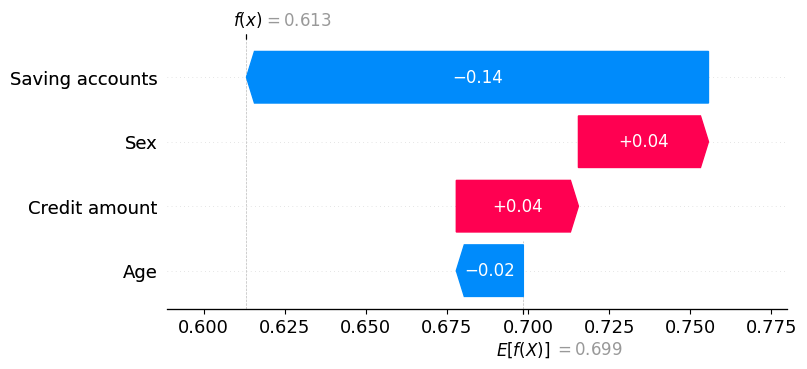

In [18]:
explanation = shap.Explanation(values=np.array(phis),
                                feature_names=feature_names,
                                base_values=get_baseline(X_test_scaled, ModelWrapper()),
                                output_names=['Prediction'])

shap.plots.waterfall(explanation)

In [19]:
explainer = CausalExplainer(X = X_test_scaled, model = ModelWrapper(), is_classification=False, rounding_precision = 1, feature_names = feature_names)
phis = explainer.compute_shapley_values(features_woman[0], effect_type= EffectType.TOTAL, causal_model=[[1], [0, 2, 3]], confounding=[False, True], is_asymmetric=True, asymmetric_causal_model={"Age": ["Saving accounts", "Credit amount"], "Sex": ["Saving accounts", "Credit amount"]})

Baseline Value (E[f(X)]):  0.7012899287503107
Predicted Value (f(x))  [0.61590864]
Shapley Values + (E[f(X)]):  0.616


In [20]:
print(f"Causal Total Asymmetric Shapley value: {phis[1]}")

Causal Total Asymmetric Shapley value: 0.04010515860658051


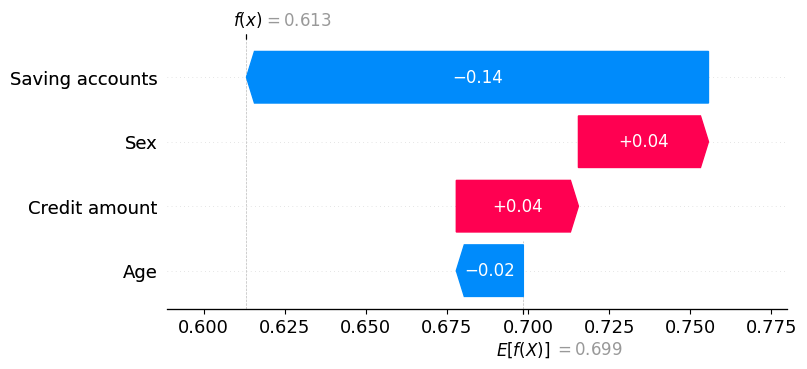

In [21]:
explanation = shap.Explanation(values=np.array(phis),
                                feature_names=feature_names,
                                base_values=get_baseline(X_test_scaled, ModelWrapper()),
                                output_names=['Prediction'])

shap.plots.waterfall(explanation)

In [22]:
explainer = CausalExplainer(X = X_test_scaled, model = ModelWrapper(), is_classification=False, rounding_precision = 1, feature_names = feature_names)
phis = explainer.compute_shapley_values(features_woman[0], effect_type= EffectType.DIRECT, causal_model=[[1], [0, 2, 3]], confounding=[False, True], is_asymmetric=False)

Baseline Value (E[f(X)]):  0.7012899287503107
Predicted Value (f(x))  [0.61590864]
Shapley Values + (E[f(X)]):  0.613


In [23]:
print(f"Direct Shapley value: {phis[1]}")

Direct Shapley value: 0.03731548941415195


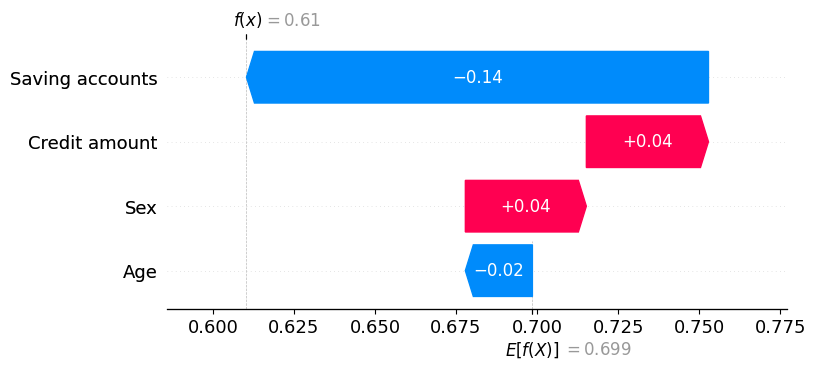

In [24]:
explanation = shap.Explanation(values=np.array(phis),
                                feature_names=feature_names,
                                base_values=get_baseline(X_test_scaled, ModelWrapper()),
                                output_names=['Prediction'])

shap.plots.waterfall(explanation)

In [25]:
explainer = CausalExplainer(X = X_test_scaled, model = ModelWrapper(), is_classification=False, rounding_precision = 1, feature_names = feature_names)
phis = explainer.compute_shapley_values(features_woman[0], effect_type= EffectType.INDIRECT, causal_model=[[1], [0, 2, 3]], confounding=[False, True], is_asymmetric=False)

Baseline Value (E[f(X)]):  0.7012899287503107
Predicted Value (f(x))  [0.61590864]
Shapley Values + (E[f(X)]):  0.704


In [26]:
print(f"Causal Indirect Shapley value: {phis[1]}")

Causal Indirect Shapley value: 0.002789670247082284


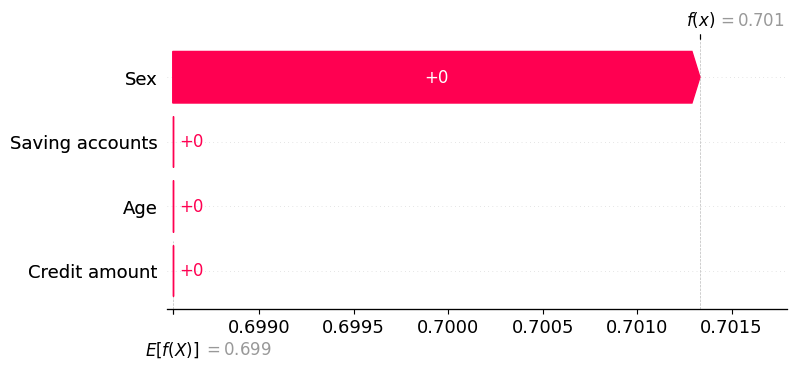

In [27]:
explanation = shap.Explanation(values=np.array(phis),
                                feature_names=feature_names,
                                base_values=get_baseline(X_test_scaled, ModelWrapper()),
                                output_names=['Prediction'])

shap.plots.waterfall(explanation)

# Marginal Shapley values

In [6]:
from shapley_values.causal_shap import Explainer, ShapleyValuesType

In [29]:
explainer = Explainer(X = X_test_scaled, model = ModelWrapper(), is_classification=False, rounding_precision = 1, feature_names = [])
phis = explainer.compute_shapley_values(features_woman[0], type = ShapleyValuesType.CONDITIONAL)

Baseline Value (E[f(X)]):  0.7012899287503107
Predicted Value (f(x))  [0.61590864]
Shapley Values + (E[f(X)]):  0.616


In [30]:
print(f"Conditional Shapley value: {phis[1]}")

Conditional Shapley value: -0.0010570663345666846


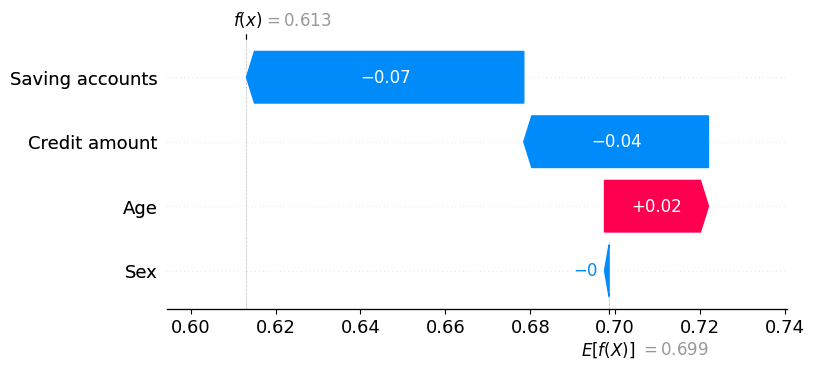

In [31]:
explanation = shap.Explanation(values=np.array(phis),
                                feature_names=feature_names,
                                base_values=get_baseline(X_test_scaled, ModelWrapper()),
                                output_names=['Prediction'])
shap.plots.waterfall(explanation)

In [32]:
explainer = Explainer(X = X_test_scaled, model = ModelWrapper(), is_classification=False, rounding_precision = 1, feature_names = [])
phis = explainer.compute_shapley_values(features_woman[0], type = ShapleyValuesType.MARGINAL)

Baseline Value (E[f(X)]):  0.7012899287503107
Predicted Value (f(x))  [0.61590864]
Shapley Values + (E[f(X)]):  0.616


In [33]:
print(f"Marginal Shapley value: {phis[1]}")

Marginal Shapley value: 0.03731548842164562


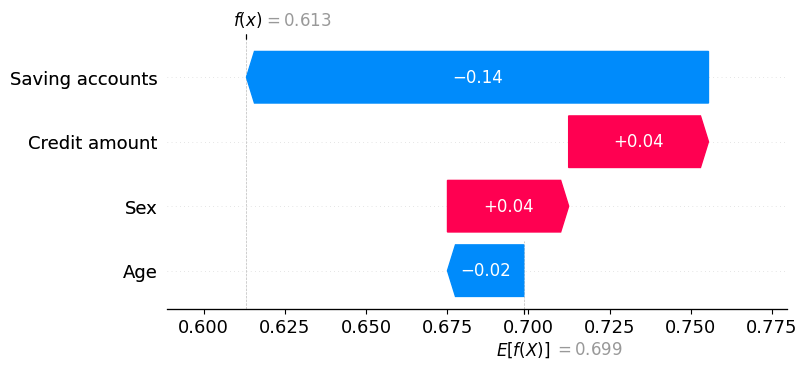

In [34]:
explanation = shap.Explanation(values=np.array(phis),
                                feature_names=feature_names,
                                base_values=get_baseline(X_test_scaled, ModelWrapper()),
                                output_names=['Prediction'])
shap.plots.waterfall(explanation)

In [35]:
explainer = Explainer(X = X_test_scaled, model = ModelWrapper(), is_classification=False, rounding_precision = 1, feature_names = feature_names)
phis = explainer.compute_shapley_values(features_woman[0], type = ShapleyValuesType.CONDITIONAL, is_asymmetric=True, causal_model={"Age": ["Saving accounts", "Credit amount"], "Sex": ["Saving accounts", "Credit amount"]})

Baseline Value (E[f(X)]):  0.7012899287503107
Predicted Value (f(x))  [0.61590864]
Shapley Values + (E[f(X)]):  0.616


In [36]:
print(f"Conditional Asymmetrix Shapley value: {phis[1]}")

Conditional Asymmetrix Shapley value: 0.0191574373195032


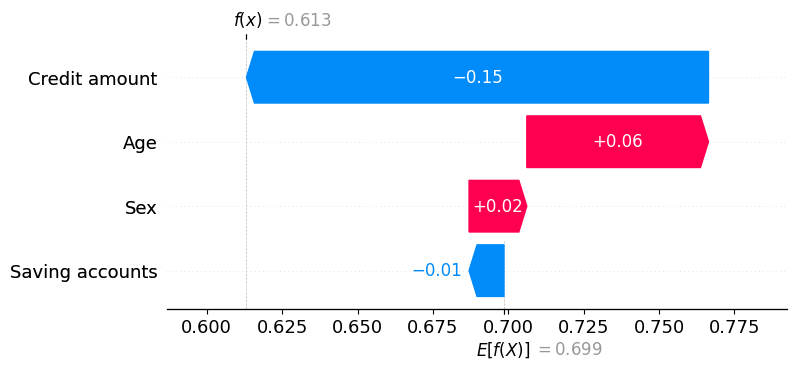

In [37]:
explanation = shap.Explanation(values=np.array(phis),
                                feature_names=feature_names,
                                base_values=get_baseline(X_test_scaled, ModelWrapper()),
                                output_names=['Prediction'])
shap.plots.waterfall(explanation)

# Pishap and Pathwise

In [39]:
from sklearn.neural_network import MLPRegressor

In [56]:
treatment_set_female = scaler.transform([[0, 1, 0, 0]])[0][1]
treatment_not_set_male = scaler.transform([[0, 0, 0, 0]])[0][1]

sample = features_woman[0]

In [104]:
treatment_col_index = gender_col_index = 1
savings_col_index = 2
amount_col_index = 3
age_col_index = 0


y_hat_model = ModelWrapper().predict(X_test_scaled)
T_test1 = X_test_scaled[:, treatment_col_index]

def train_inner_models(X, y, T):
    """
    Train T-learner models using treated and control splits,
    excluding treatment column from features.
    """
    # Remove treatment column from features to avoid leakage
    X_no_treatment = np.delete(X, treatment_col_index, axis=1)

    X_treated = X_no_treatment[T == treatment_set_female]
    y_treated = y[T == treatment_set_female]
    X_control = X_no_treatment[T == treatment_not_set_male]
    y_control = y[T == treatment_not_set_male]
    
    model_mu1 = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    model_mu1.fit(X_treated, y_treated)
    model_mu0 = MLPRegressor(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    model_mu0.fit(X_control, y_control)

    return model_mu1, model_mu0

def predict_cate(model_mu1, model_mu0, X):
    # Remove treatment column before prediction
    T = X[:, treatment_col_index]
    X_1 = X[T == treatment_set_female]
    X_0 = X[T == treatment_not_set_male]

    X_0=np.delete(X_0, treatment_col_index, axis=1)
    X_1=np.delete(X_1, treatment_col_index, axis=1)

    mu1 = model_mu1.predict(X_1)
    mu0 = model_mu0.predict(X_0)

    cate_mean = np.mean(mu1) - np.mean(mu0)
    return mu1, mu0, cate_mean

# === Train models on full dataset ===
def filter_close(X, col_idx, val, tol=0.2):
    return np.abs(X[:, col_idx] - val) < tol

model_mu1, model_mu0 = train_inner_models(X_test_scaled, y_hat_model, T_test1)

# === 1. Full data (all mediators present) ===
# E[Y | do (T = 1)] -  E[Y | do (T = 0)]
mu1_full, mu0_full, ate = predict_cate(model_mu1, model_mu0, X_test_scaled)

# === 2. Remove Mediator 1: filter by mediator2 + confounder only ===
# E[Y | do (T = 1), M1 = m1] -  E[Y | do (T = 0), M1 = m1]
mask_savings = filter_close(X_test_scaled, savings_col_index, sample[savings_col_index])
X_filtered_savings = X_test_scaled[mask_savings]
mu1_m2, mu0_m2, cate_savings = predict_cate(model_mu1, model_mu0, X_filtered_savings)


# === 3. Remove Mediator 2: filter by mediator1 + confounder only ===
mask_amount = filter_close(X_test_scaled, amount_col_index, sample[amount_col_index])
X_filtered_amount = X_test_scaled[mask_amount]
mu1_m1, mu0_m1, cate_amount = predict_cate(model_mu1, model_mu0, X_filtered_amount)


# === 4. Remove Both Mediators: filter by confounder only ===

mask_savings_age = filter_close(X_test_scaled, savings_col_index, sample[savings_col_index])& \
            filter_close(X_test_scaled, age_col_index, sample[age_col_index])
X_filtered_savings_age = X_test_scaled[mask_savings_age]

mu1_m2, mu0_m2, cate_savings_age = predict_cate(model_mu1, model_mu0, X_filtered_savings_age)


mask_amount_age= filter_close(X_test_scaled, amount_col_index, sample[amount_col_index])& \
            filter_close(X_test_scaled, age_col_index, sample[age_col_index])
X_filtered_amount_age = X_test_scaled[mask_amount_age]
mu1_m1, mu0_m1, cate_amount_age = predict_cate(model_mu1, model_mu0, X_filtered_amount_age)


mask_savings_amount_age = filter_close(X_test_scaled, amount_col_index, sample[amount_col_index]) & \
            filter_close(X_test_scaled, savings_col_index, sample[savings_col_index]) & \
            filter_close(X_test_scaled, age_col_index, sample[age_col_index])


X_filtered_mask_savings_amount_age = X_test_scaled[mask_savings_amount_age]

mu1_conf, mu0_conf, cate_savings_amount_age = predict_cate(model_mu1, model_mu0, X_filtered_mask_savings_amount_age)

# === Compute Path-wise SHAP values (effects) ===
path_wise_shap_t_amount_y = cate_savings_amount_age - cate_savings_age
path_wise_shap_t_savings_y = cate_savings_amount_age - cate_amount_age

pishap_t_amount_y = ate - cate_amount
pishap_t_savings_y = ate - cate_savings

In [105]:
path_wise_shap_t_amount_y

np.float64(0.05395659430271471)

In [106]:
path_wise_shap_t_savings_y

np.float64(0.04453838302028246)

In [107]:
pishap_t_amount_y

np.float64(-0.0359565133658738)

In [108]:
pishap_t_savings_y

np.float64(-0.05449638472303053)

# ------------

In [7]:
from simulation import path_wise_dataset_1, path_wise_dataset_gt, treatment_col_index, mediator1_col_index, mediator2_col_index, confounder_col_index, calculate_true_cate_but_mediator2, ModelWrapperGT

In [10]:
X_test, y_test = path_wise_dataset_gt(num_samples=5000)

In [11]:
explainer = Explainer(X = X_test, model = ModelWrapperGT(), is_classification=False, rounding_precision = 1, feature_names = [])
phis = explainer.compute_shapley_values([1, 0.2, 0.6, 1], type = ShapleyValuesType.CONDITIONAL)

0.0
[(1, 2, 3, 0)]
0.0
[(3, 2, 1, 0)]
0.20770456901262968
[(1, 0, 3, 2)]


KeyboardInterrupt: 